In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

matches = pd.read_csv('../dataset/matches.csv')
deliveries = pd.read_csv('../dataset/deliveries.csv')

print("Data loaded successfully!")

Data loaded successfully!


In [23]:
# Fix team name inconsistencies
team_name_map = {
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Delhi Capitals': 'Delhi Daredevils',
    'Punjab Kings': 'Kings XI Punjab',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}

matches.replace(team_name_map, inplace=True)
deliveries.replace(team_name_map, inplace=True)

print("Team names standardised!")

Team names standardised!


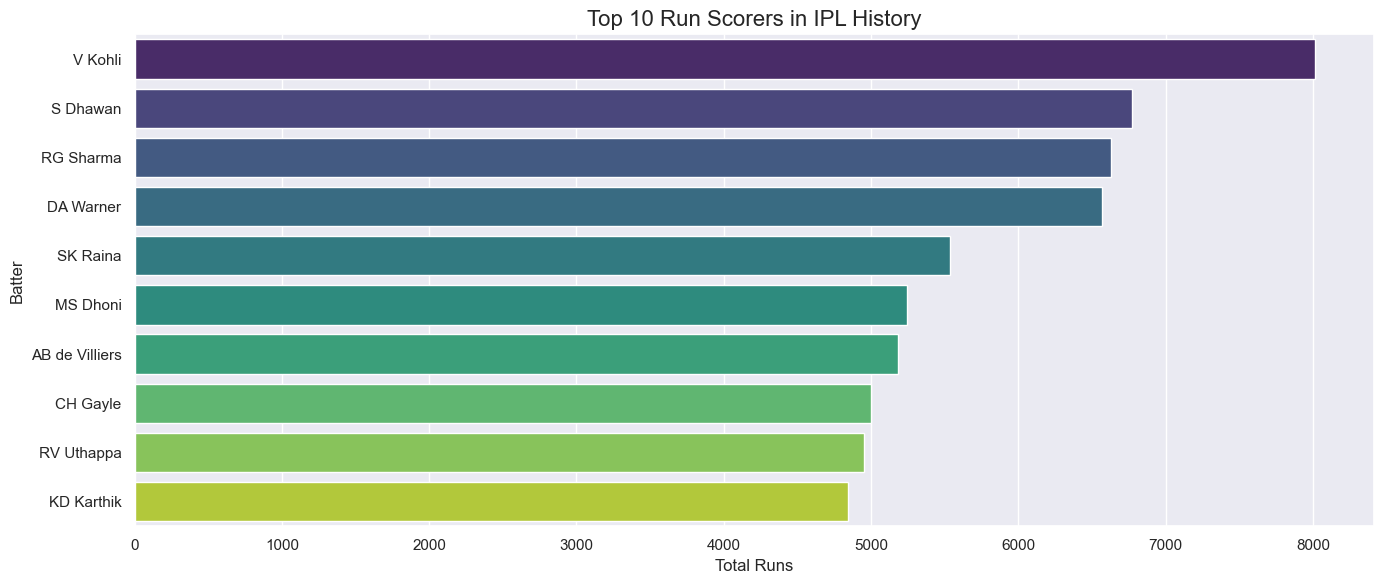

In [24]:
top_scorers = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, hue=top_scorers.index, palette='viridis', legend=False)
plt.title('Top 10 Run Scorers in IPL History', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

In [25]:
top_scorers_table = deliveries.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batsman_runs', 'count'),
    fours=('batsman_runs', lambda x: (x == 4).sum()),
    sixes=('batsman_runs', lambda x: (x == 6).sum())
).reset_index()

top_scorers_table['strike_rate'] = (top_scorers_table['runs'] / top_scorers_table['balls'] * 100).round(2)
top_scorers_table = top_scorers_table.sort_values('runs', ascending=False).head(10)
top_scorers_table

,batter,runs,balls,fours,sixes,strike_rate
631,V Kohli,8014,6236,708,273,128.51
512,S Dhawan,6769,5483,768,153,123.45
477,RG Sharma,6630,5183,599,281,127.92
147,DA Warner,6567,4849,663,236,135.43
546,SK Raina,5536,4177,506,204,132.54
374,MS Dhoni,5243,3947,363,252,132.84
30,AB de Villiers,5181,3487,414,253,148.58
124,CH Gayle,4997,3516,408,359,142.12
501,RV Uthappa,4954,3927,481,182,126.15
282,KD Karthik,4843,3687,466,161,131.35


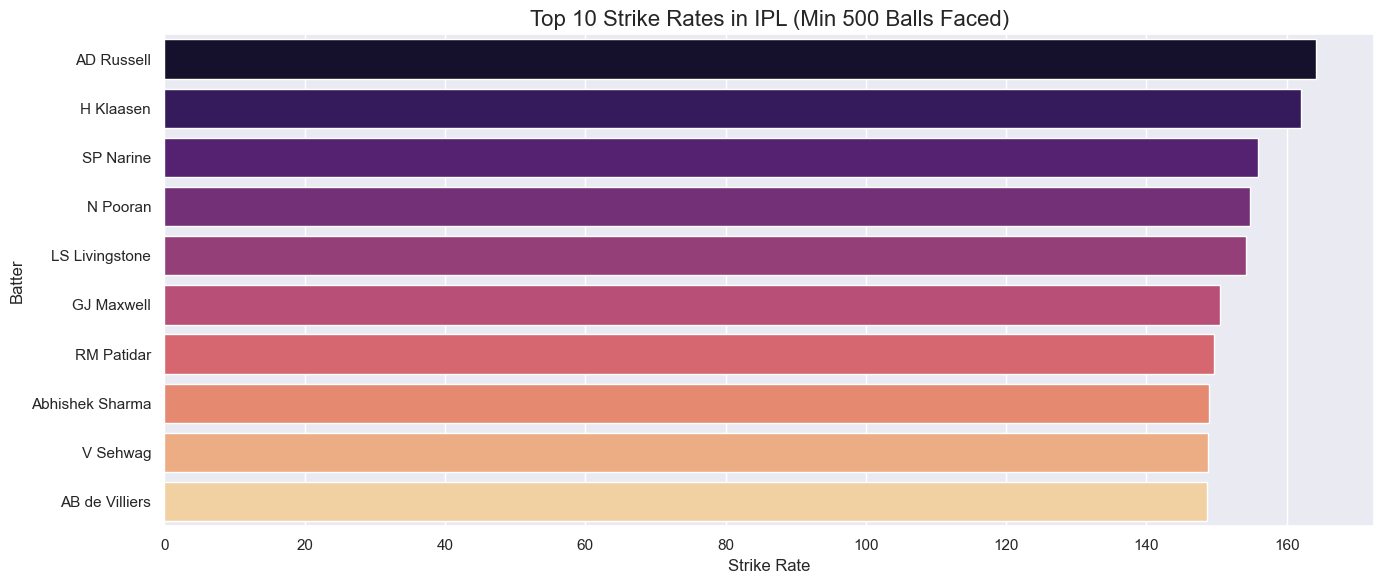

In [26]:
strike_rates = deliveries.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batsman_runs', 'count')
).reset_index()

strike_rates = strike_rates[strike_rates['balls'] >= 500]
strike_rates['strike_rate'] = (strike_rates['runs'] / strike_rates['balls'] * 100).round(2)
strike_rates = strike_rates.sort_values('strike_rate', ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=strike_rates['strike_rate'], y=strike_rates['batter'], hue=strike_rates['batter'], palette='magma', legend=False)
plt.title('Top 10 Strike Rates in IPL (Min 500 Balls Faced)', fontsize=16)
plt.xlabel('Strike Rate')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

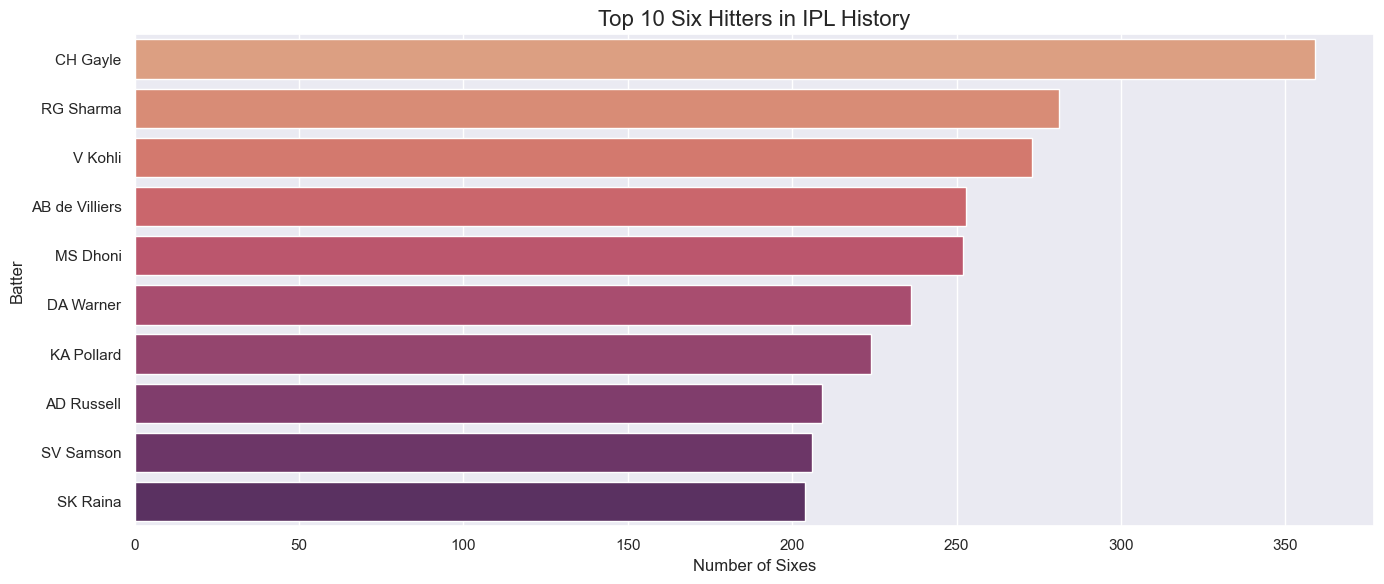

In [27]:
sixes = deliveries[deliveries['batsman_runs'] == 6].groupby('batter').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=sixes.values, y=sixes.index, hue=sixes.index, palette='flare', legend=False)
plt.title('Top 10 Six Hitters in IPL History', fontsize=16)
plt.xlabel('Number of Sixes')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

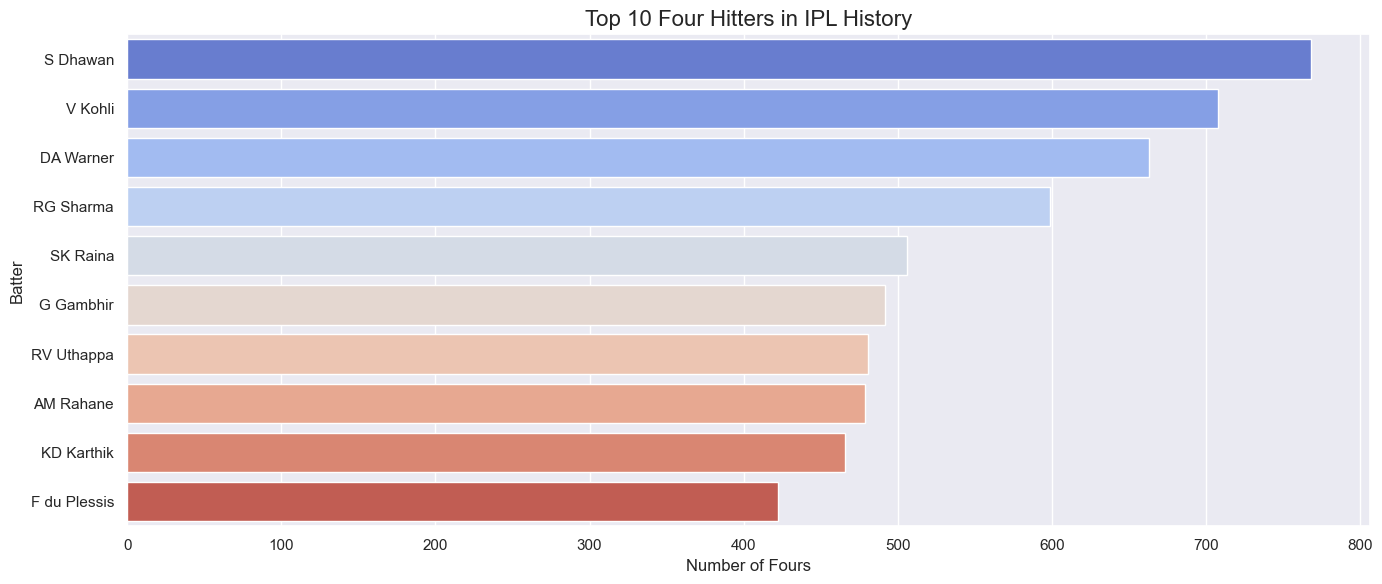

In [28]:
fours = deliveries[deliveries['batsman_runs'] == 4].groupby('batter').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=fours.values, y=fours.index, hue=fours.index, palette='coolwarm', legend=False)
plt.title('Top 10 Four Hitters in IPL History', fontsize=16)
plt.xlabel('Number of Fours')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

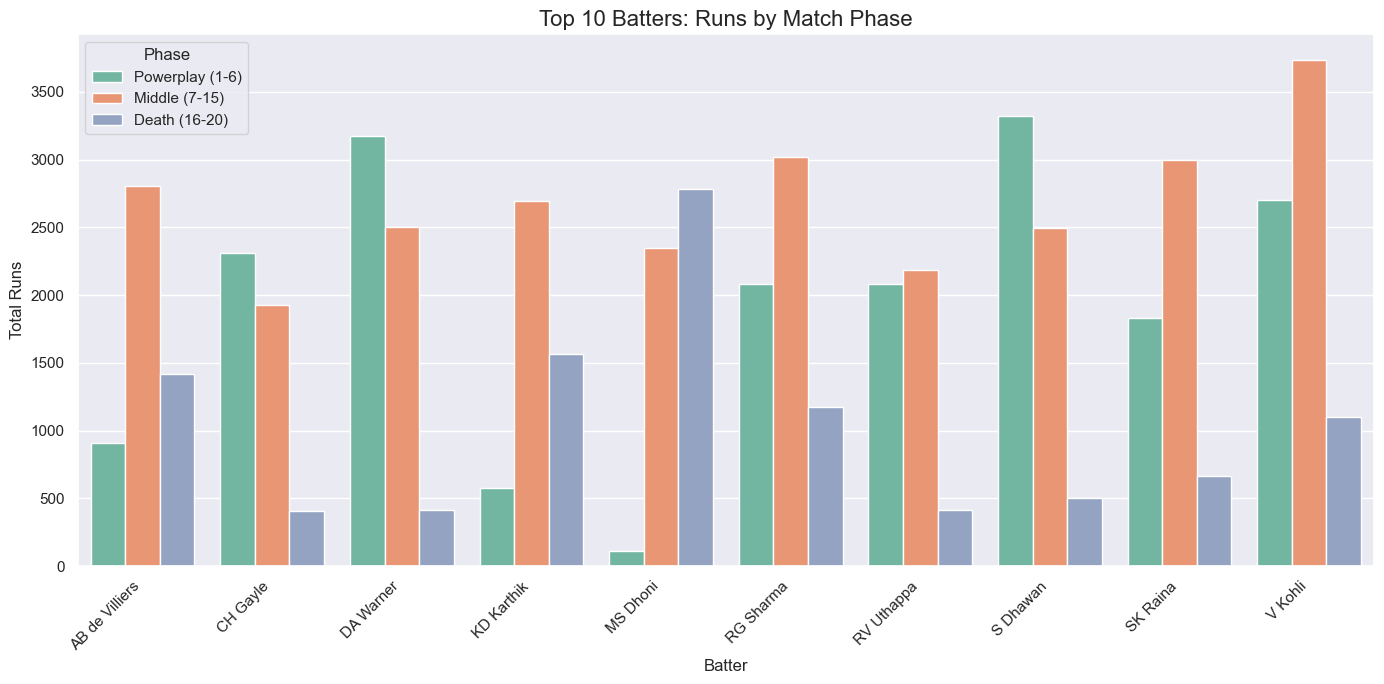

In [29]:
deliveries['phase'] = pd.cut(deliveries['over'],
                              bins=[0, 6, 15, 20],
                              labels=['Powerplay (1-6)', 'Middle (7-15)', 'Death (16-20)'])

phase_runs = deliveries.groupby(['batter', 'phase'], observed=True)['batsman_runs'].sum().reset_index()
top_batters = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10).index
phase_runs_top = phase_runs[phase_runs['batter'].isin(top_batters)]

plt.figure(figsize=(14, 7))
sns.barplot(data=phase_runs_top, x='batter', y='batsman_runs', hue='phase', palette='Set2')
plt.title('Top 10 Batters: Runs by Match Phase', fontsize=16)
plt.xlabel('Batter')
plt.ylabel('Total Runs')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Phase')
plt.tight_layout()
plt.show()

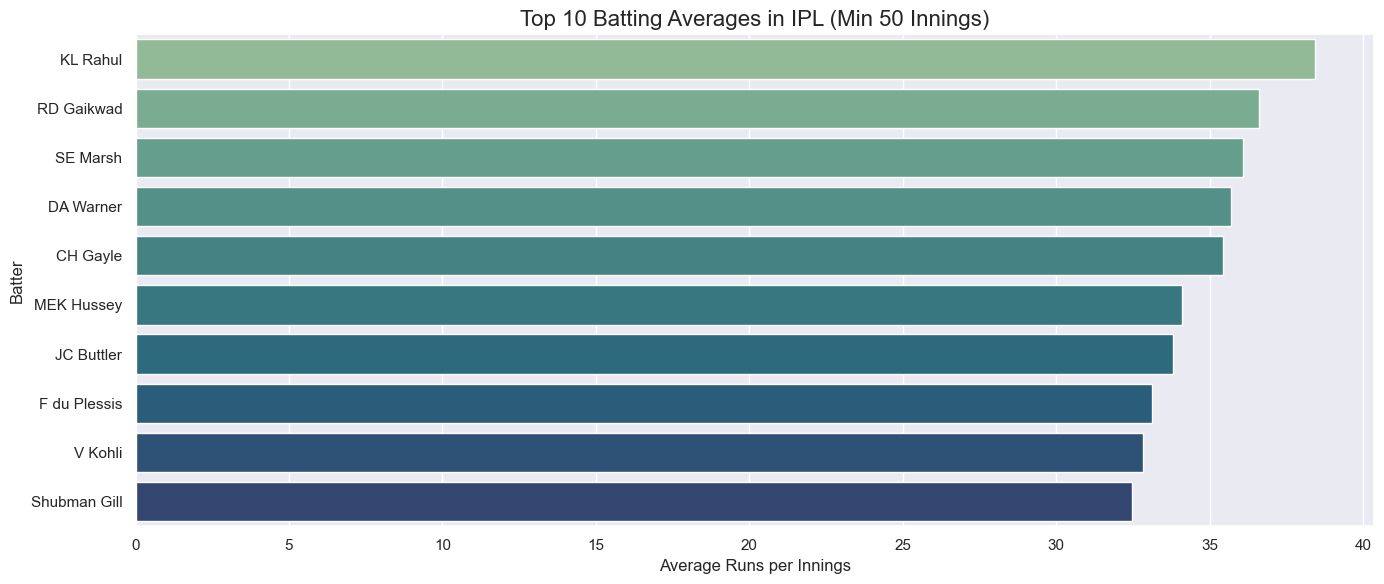

In [30]:
batter_match_runs = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index()
batter_avg = batter_match_runs.groupby('batter').agg(
    total_runs=('batsman_runs', 'sum'),
    innings=('batsman_runs', 'count'),
    avg=('batsman_runs', 'mean')
).reset_index()

batter_avg = batter_avg[batter_avg['innings'] >= 50]
batter_avg = batter_avg.sort_values('avg', ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=batter_avg['avg'], y=batter_avg['batter'], hue=batter_avg['batter'], palette='crest', legend=False)
plt.title('Top 10 Batting Averages in IPL (Min 50 Innings)', fontsize=16)
plt.xlabel('Average Runs per Innings')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

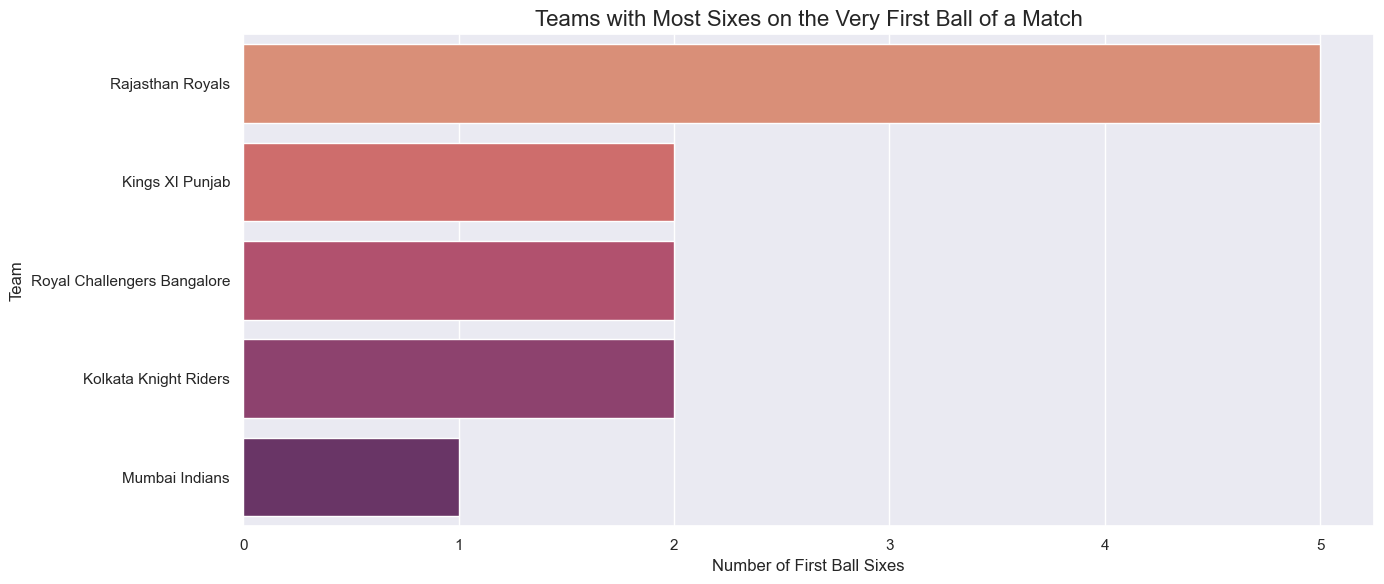


=== FIRST BALL SIX COUNTS ===
batting_team
Rajasthan Royals               5
Kings XI Punjab                2
Royal Challengers Bangalore    2
Kolkata Knight Riders          2
Mumbai Indians                 1
Name: count, dtype: int64

Total first ball sixes in IPL history: 12


In [31]:
first_ball_sixes = deliveries[(deliveries['over'] == 0) & 
                               (deliveries['ball'] == 1) & 
                               (deliveries['batsman_runs'] == 6)]

first_ball_six_counts = first_ball_sixes['batting_team'].value_counts()

plt.figure(figsize=(14, 6))
sns.barplot(x=first_ball_six_counts.values, y=first_ball_six_counts.index, 
            hue=first_ball_six_counts.index, palette='flare', legend=False)
plt.title('Teams with Most Sixes on the Very First Ball of a Match', fontsize=16)
plt.xlabel('Number of First Ball Sixes')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

print("\n=== FIRST BALL SIX COUNTS ===")
print(first_ball_six_counts)
print(f"\nTotal first ball sixes in IPL history: {len(first_ball_sixes)}")

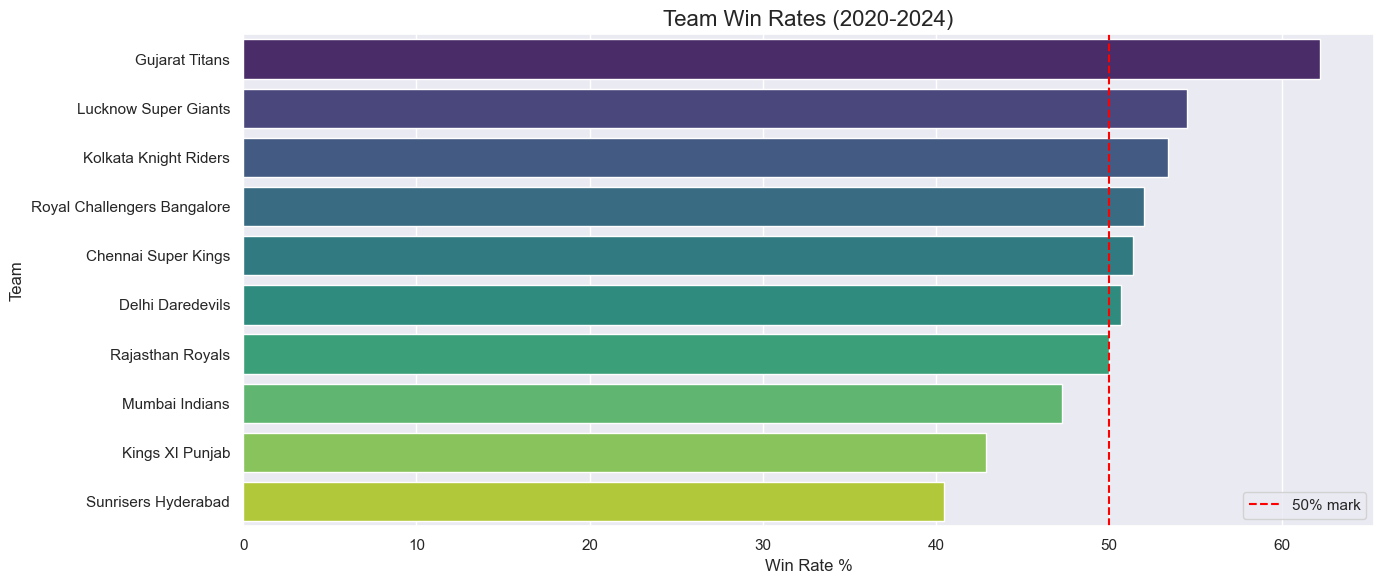


=== WIN RATES (2020-2024) ===
                       team  played  won  win_rate
             Gujarat Titans      45   28      62.2
       Lucknow Super Giants      44   24      54.5
      Kolkata Knight Riders      73   39      53.4
Royal Challengers Bangalore      75   39      52.0
        Chennai Super Kings      74   38      51.4
           Delhi Daredevils      75   38      50.7
           Rajasthan Royals      74   37      50.0
             Mumbai Indians      74   35      47.3
            Kings XI Punjab      70   30      42.9
        Sunrisers Hyderabad      74   30      40.5


In [32]:
# Filter matches from last 5 seasons (2020 onwards)
recent_seasons = ['2020/21', '2021', '2022', '2023', '2024']
recent_matches = matches[matches['season'].isin(recent_seasons)]
recent_deliveries = deliveries[deliveries['match_id'].isin(recent_matches['id'])]

# --- ANALYSIS 1: Win Rate by Team (last 5 seasons) ---
all_teams_recent = pd.concat([recent_matches['team1'], recent_matches['team2']]).unique()

win_rates = []
for team in all_teams_recent:
    played = recent_matches[(recent_matches['team1'] == team) | (recent_matches['team2'] == team)]
    won = recent_matches[recent_matches['winner'] == team]
    win_rate = len(won) / len(played) * 100
    win_rates.append({'team': team, 'played': len(played), 'won': len(won), 'win_rate': round(win_rate, 1)})

win_rates_df = pd.DataFrame(win_rates).sort_values('win_rate', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=win_rates_df, x='win_rate', y='team', hue='team', palette='viridis', legend=False)
plt.title('Team Win Rates (2020-2024)', fontsize=16)
plt.xlabel('Win Rate %')
plt.ylabel('Team')
plt.axvline(x=50, color='red', linestyle='--', label='50% mark')
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== WIN RATES (2020-2024) ===")
print(win_rates_df.to_string(index=False))

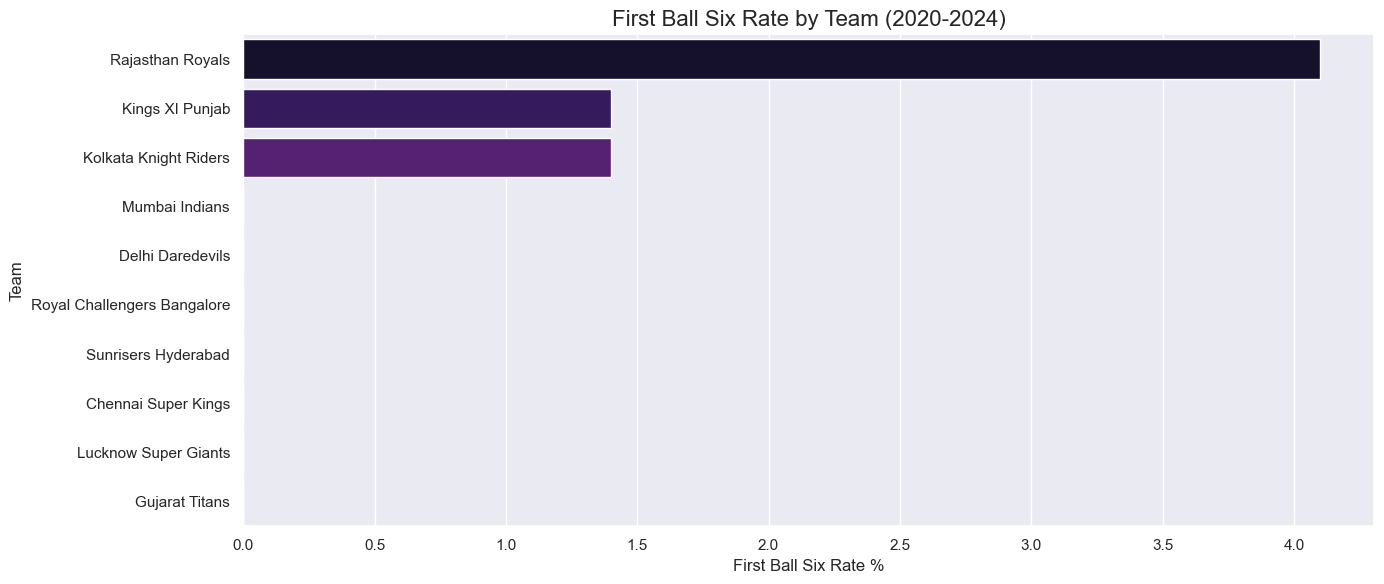


=== FIRST BALL SIX RATES (2020-2024) ===
                       team  innings  first_ball_sixes  six_rate
           Rajasthan Royals       74                 3       4.1
            Kings XI Punjab       73                 1       1.4
      Kolkata Knight Riders       74                 1       1.4
             Mumbai Indians       77                 0       0.0
           Delhi Daredevils       77                 0       0.0
Royal Challengers Bangalore       76                 0       0.0
        Sunrisers Hyderabad       76                 0       0.0
        Chennai Super Kings       73                 0       0.0
       Lucknow Super Giants       44                 0       0.0
             Gujarat Titans       45                 0       0.0


In [33]:
# --- ANALYSIS 2: First Ball Six Rate by Team (last 5 seasons) ---
first_ball_recent = recent_deliveries[(recent_deliveries['over'] == 0) & 
                                       (recent_deliveries['ball'] == 1)]

first_ball_six_rate = []
for team in all_teams_recent:
    team_first_balls = first_ball_recent[first_ball_recent['batting_team'] == team]
    total = len(team_first_balls)
    sixes = len(team_first_balls[team_first_balls['batsman_runs'] == 6])
    if total > 0:
        rate = sixes / total * 100
        first_ball_six_rate.append({'team': team, 'innings': total, 'first_ball_sixes': sixes, 'six_rate': round(rate, 1)})

six_rate_df = pd.DataFrame(first_ball_six_rate).sort_values('six_rate', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=six_rate_df, x='six_rate', y='team', hue='team', palette='magma', legend=False)
plt.title('First Ball Six Rate by Team (2020-2024)', fontsize=16)
plt.xlabel('First Ball Six Rate %')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

print("\n=== FIRST BALL SIX RATES (2020-2024) ===")
print(six_rate_df.to_string(index=False))

In [34]:
# --- ANALYSIS 3: Combined Summary ---
combined = win_rates_df.merge(six_rate_df[['team', 'six_rate', 'first_ball_sixes']], on='team')
combined = combined.sort_values('win_rate', ascending=False)

print("\n=== COMBINED SUMMARY (2020-2024) ===")
print(combined[['team', 'played', 'won', 'win_rate', 'first_ball_sixes', 'six_rate']].to_string(index=False))


=== COMBINED SUMMARY (2020-2024) ===
                       team  played  won  win_rate  first_ball_sixes  six_rate
             Gujarat Titans      45   28      62.2                 0       0.0
       Lucknow Super Giants      44   24      54.5                 0       0.0
      Kolkata Knight Riders      73   39      53.4                 1       1.4
Royal Challengers Bangalore      75   39      52.0                 0       0.0
        Chennai Super Kings      74   38      51.4                 0       0.0
           Delhi Daredevils      75   38      50.7                 0       0.0
           Rajasthan Royals      74   37      50.0                 3       4.1
             Mumbai Indians      74   35      47.3                 0       0.0
            Kings XI Punjab      70   30      42.9                 1       1.4
        Sunrisers Hyderabad      74   30      40.5                 0       0.0


In [35]:
total_runs = deliveries['batsman_runs'].sum()
total_sixes = (deliveries['batsman_runs'] == 6).sum()
total_fours = (deliveries['batsman_runs'] == 4).sum()
top_scorer = deliveries.groupby('batter')['batsman_runs'].sum().idxmax()
top_scorer_runs = deliveries.groupby('batter')['batsman_runs'].sum().max()
most_sixes = deliveries[deliveries['batsman_runs'] == 6].groupby('batter').size().idxmax()
most_fours = deliveries[deliveries['batsman_runs'] == 4].groupby('batter').size().idxmax()

print("=== BATTING SUMMARY ===")
print(f"Total runs scored in IPL history: {total_runs:,}")
print(f"Total sixes hit: {total_sixes:,}")
print(f"Total fours hit: {total_fours:,}")
print(f"All time top scorer: {top_scorer} ({top_scorer_runs:,} runs)")
print(f"Most sixes in IPL history: {most_sixes}")
print(f"Most fours in IPL history: {most_fours}")

=== BATTING SUMMARY ===
Total runs scored in IPL history: 330,064
Total sixes hit: 13,051
Total fours hit: 29,850
All time top scorer: V Kohli (8,014 runs)
Most sixes in IPL history: CH Gayle
Most fours in IPL history: S Dhawan
